# Customer Segmentation Analysis for Online Retail

## Project Objective

This project analyzes online retail transaction data to understand customer behavior and identify high-value customer segments.

The goal is to use RFM analysis and revenue concentration analysis to support business decisions such as customer retention and revenue growth.

The analysis is implemented using Python (pandas, matplotlib) for data processing and visualization.

## Data Overview

In [8]:
import pandas as pd

df = pd.read_excel('Online Retail.xlsx')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
df.shape

(541909, 8)

In [11]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [12]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

This dataset contain online retail transaction records.
It includes information such as InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country.
The dataset has 541909 rows, which makes it useful for analysis.

## Data Cleaning

In [13]:
df = df.dropna(subset=['CustomerID'])

In [14]:
df = df[df['Quantity'] > 0]

In [15]:
df = df[df['UnitPrice'] > 0]

In [16]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [17]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [18]:
df.shape

(397884, 9)

Rows with missing customer IDs were removed because customer information is necessary for customer-level analysis.  
Transactions with non-positive quantity or unit price were also removed to exclude returns and invalid records.  
A new variable, TotalPrice, was created to measure transaction-level revenue.

## Sales and Product Analysis

### Sales Analysis

In [19]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [20]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

In [21]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

In [22]:
monthly_sales

Month
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: TotalPrice, dtype: float64

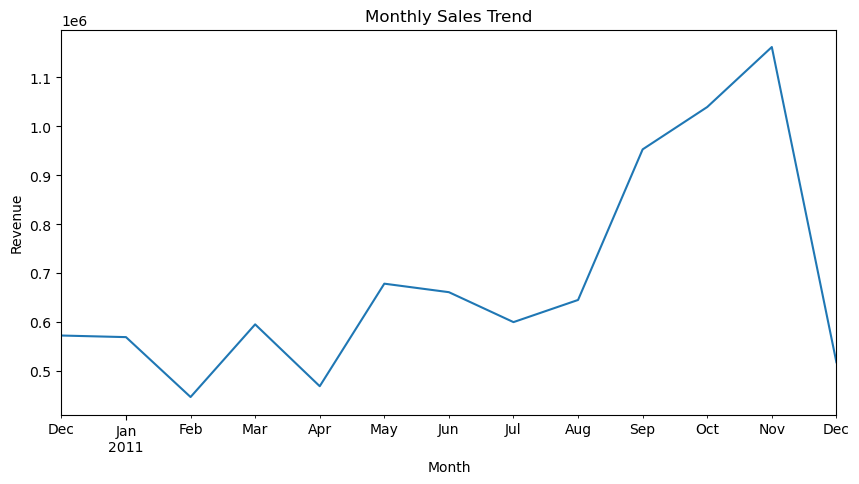

In [23]:
import matplotlib.pyplot as plt

monthly_sales.plot(figsize=(10,5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

Sales tend to increase at the end of the year, with peaks observed in November and December.
This pattern may be related to the discount activities.


### Product Analysis

In [24]:
product_sales = df.groupby("Description")['TotalPrice'].sum()
product_sales = product_sales.sort_values(ascending = False)
product_sales.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: TotalPrice, dtype: float64

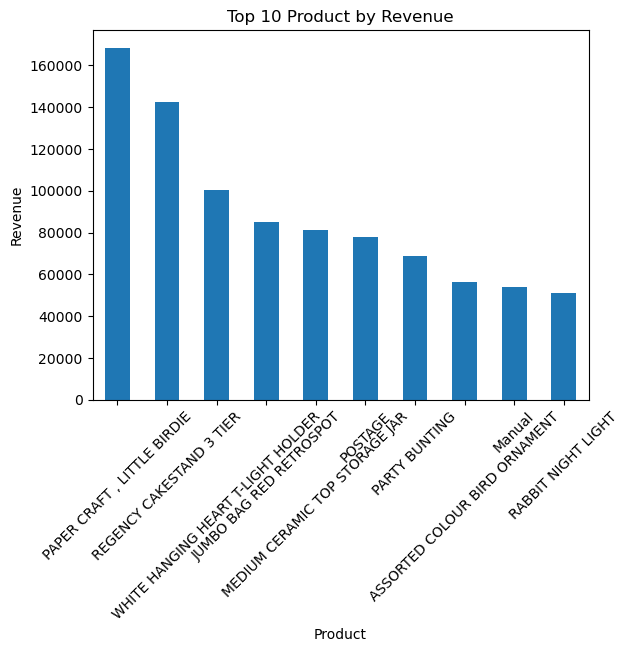

In [25]:
top10 = product_sales.head(10)

top10.plot(kind='bar')
plt.title('Top 10 Product by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

## Revenue Concentration Analysis (Pareto)

This section analyzes how revenue is distributed across products and evaluates whether a small proportion of products contributes most of the total revenue.

In [26]:
product_sales_cum = product_sales.cumsum()
product_sales_cum_pct = product_sales_cum / product_sales.sum()

product_sales_cum_pct.head(-5)

Description
PAPER CRAFT , LITTLE BIRDIE            0.018905
REGENCY CAKESTAND 3 TIER               0.034906
WHITE HANGING HEART T-LIGHT HOLDER     0.046178
JUMBO BAG RED RETROSPOT                0.055741
MEDIUM CERAMIC TOP STORAGE JAR         0.064877
                                         ...   
RUBY GLASS CLUSTER EARRINGS            0.999999
60 GOLD AND SILVER FAIRY CAKE CASES    0.999999
CAT WITH SUNGLASSES BLANK CARD         0.999999
HAPPY BIRTHDAY CARD TEDDY/CAKE         1.000000
PINK CRYSTAL GUITAR PHONE CHARM        1.000000
Name: TotalPrice, Length: 3872, dtype: float64

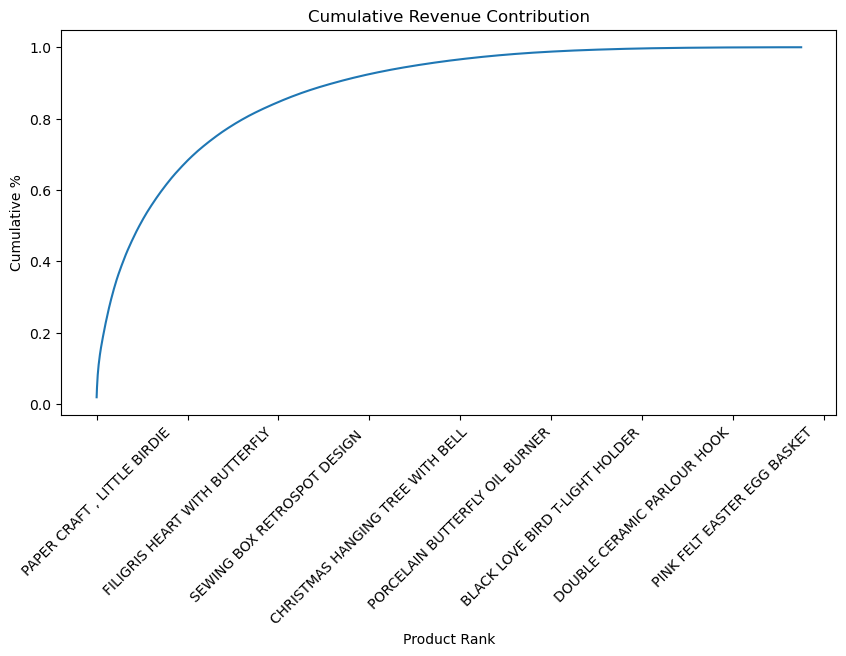

In [27]:
product_sales_cum_pct.plot(figsize=(10,5))
plt.title("Cumulative Revenue Contribution")
plt.xlabel("Product Rank")
plt.ylabel("Cumulative %")
plt.xticks(rotation=45)
plt.show()

In [28]:
(product_sales_cum_pct < 0.8).sum()

np.int64(810)

In [29]:
top_10_percent = int(len(product_sales) * 0.1)
product_sales_cum_pct.iloc[top_10_percent]

np.float64(0.6176636620493329)

In [30]:
top_20_percent = int(len(product_sales) * 0.2)
product_sales_cum_pct.iloc[top_20_percent]

np.float64(0.7898974242712441)

The cumulative curve increase rapidly at the beginning and then gradually flattens.

The top 10% of products account for about 62% of total revenue, while the 20% contribute close to 80%, suggesting a moderately concentrated distribution.

This pattern indicates that a small group of products plays a dominant role in revenue generation, which can be useful for inventory planning and marketing focus.

## RFM Analysis

RFM analysis evaluates customer value based on recency, frequency, and monetary metrics.

In [31]:
snapshot_date = df['InvoiceDate'].max()
snapshot_date

Timestamp('2011-12-09 12:50:00')

In [32]:
rfm = df.groupby('CustomerID').agg({'InvoiceDate':'max', 'InvoiceNo': 'count', 'TotalPrice':'sum'})
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm['Recency'] = (snapshot_date - rfm['Recency']).dt.days

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,182,4310.00
12348.0,74,31,1797.24
12349.0,18,73,1757.55
12350.0,309,17,334.40


In [33]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,91.720609,2054.266460
std,100.014169,228.785094,8989.230441
min,0.000000,1.000000,3.750000
25%,17.000000,17.000000,307.415000
50%,50.000000,41.000000,674.485000
75%,141.000000,100.000000,1661.740000
max,373.000000,7847.000000,280206.020000


## Customer Segmentation

Customers are grouped into segments based on their RFM scores.

In [34]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'], 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score
CustomerID,,,,,,
12346.0,325,1,77183.60,1,1,4
12347.0,1,182,4310.00,4,4,4
12348.0,74,31,1797.24,2,2,4
12349.0,18,73,1757.55,3,3,4
12350.0,309,17,334.40,1,1,2


In [35]:
rfm['RFM_score'] = (
    rfm['R_score'].astype(str) + 
    rfm['F_score'].astype(str) + 
    rfm['M_score'].astype(str))
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
CustomerID,,,,,,,
12346.0,325,1,77183.60,1,1,4,114
12347.0,1,182,4310.00,4,4,4,444
12348.0,74,31,1797.24,2,2,4,224
12349.0,18,73,1757.55,3,3,4,334
12350.0,309,17,334.40,1,1,2,112


In [36]:
def segment(row):
    if row['R_score'] == 4 and row['F_score'] == 4 and row['M_score'] == 4:
        return 'Best Customers'
    elif row['R_score'] == 1:
        return 'Lost Customers'
    elif row['F_score'] >= 3:
        return 'Loyal Customers'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment, axis=1)
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
CustomerID,,,,,,,,
12346.0,325,1,77183.60,1,1,4,114,Lost Customers
12347.0,1,182,4310.00,4,4,4,444,Best Customers
12348.0,74,31,1797.24,2,2,4,224,Others
12349.0,18,73,1757.55,3,3,4,334,Loyal Customers
12350.0,309,17,334.40,1,1,2,112,Lost Customers


Customers were assigned to four segments based on their RFM scores.

- Best Customers: customers with the highest scores in Recency, Frequency, and Monetary value (4-4-4)
- Lost Customers: customers with very low recency scores, indicating they have not purchased recently
- Loyal Customers: customers with relatively high purchase frequency
- Others: customers who do not fall into the categories above

In [37]:
rfm['Segment'].value_counts()

Segment
Loyal Customers    1497
Others             1310
Lost Customers     1084
Best Customers      447
Name: count, dtype: int64

In [38]:
rfm_summary = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
})
rfm_summary

,Recency,Frequency,Monetary
Segment,,,
Best Customers,6.279642,374.447427,9319.207964
Lost Customers,245.980627,29.505535,652.415232
Loyal Customers,39.386774,115.070808,2055.439880
Others,52.422137,20.046565,733.977353


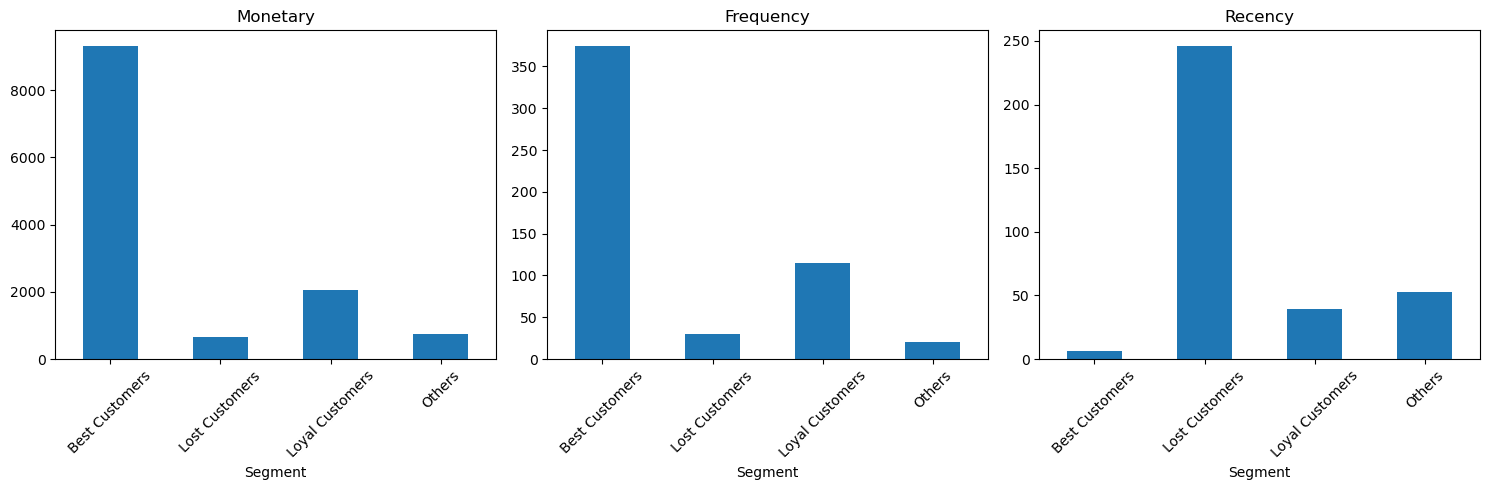

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

rfm_summary['Monetary'].plot(kind='bar', ax=axes[0], title='Monetary')
rfm_summary['Frequency'].plot(kind='bar', ax=axes[1], title='Frequency')
rfm_summary['Recency'].plot(kind='bar', ax=axes[2], title='Recency')

for ax in axes:
    ax.set_xticklabels(rfm_summary.index, rotation=45)

plt.tight_layout()
plt.show()

## Segment-Level Insights

The following insights summarize the key differences across customer segments based on RFM metrics.

The RFM analysis shows clear differences across customer groups.

Best Customers have the lowest recency, highest purchase frequency, and highest average spending, which makes them the most valuable customer group.

Loyal Customers form the largest segment and generate stable revenue through relatively frequent purchases.

Lost Customers have the highest recency values and relatively low spending, suggesting that they have not purchased for a long time and may require reactivation strategies.

Others show moderate behavior across the three dimensions and may represent customers with potential for further development.

## Conclusion

This project demonstrates how customer segmentation can be used to understand purchasing behavior and identify high-value customers.

The results show that a small group of customers contributes a large portion of revenue, while other groups require different engagement strategies.

RFM analysis provides a simple but effective way to support business decisions such as targeted marketing and customer retention.